$$
\mathbb{E}_{\text{val}}
\left[
|\nabla \log \hat f|^2
+
2 \Delta \log \hat f
\right].
$$

$$
\nabla_x \log f(x)
=
- \frac{1}{\sigma^2}
\frac{\int_{\mathcal M} p_{\theta,\sigma^2}(x),\log_x(\theta)\, dG(\theta)}
{\int_{\mathcal M} p_{\theta,\sigma^2}(x)\, dG(\theta)}.
$$
$$
p_{\theta,\sigma^2}(x) \propto \exp\left(-\frac{d^2(x,\theta)}{2\sigma^2}\right)
$$

$$
\nabla_x \log f(x)
=
- \frac{1}{\sigma^2}
\frac{\int_{\mathcal M} \exp(-\frac{d^2(x,\theta)}{2\sigma^2})\log_x(\theta)\, dG(\theta)}
{\int_{\mathcal M} \exp(-\frac{d^2(x,\theta)}{2\sigma^2})\, dG(\theta)}.
$$

In [9]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *


manifold_type = 'S1'
manifold = get_manifold(manifold_type)

In [13]:
n_samples = 5000
sigma2 = .1

# prior param
num_modes = 4
tau2 = 0.05
G =  lambda n: multimodal_sampler(manifold_type, n, tau2, num_modes) 
# G = lambda n: equator_sampler(manifold_type, n,  tau2)

# for empirical density estimation
rho = 1e-3

# for oracle approximation
num_oracle_samples = 10000

# for crossvalidation
M_grid = np.arange(1,20,1)


In [14]:
Theta = multimodal_sampler(manifold_type, n_samples, tau2, num_modes)
X = manifold.random_riemannian_normal(Theta, 1./(sigma2), n_samples)

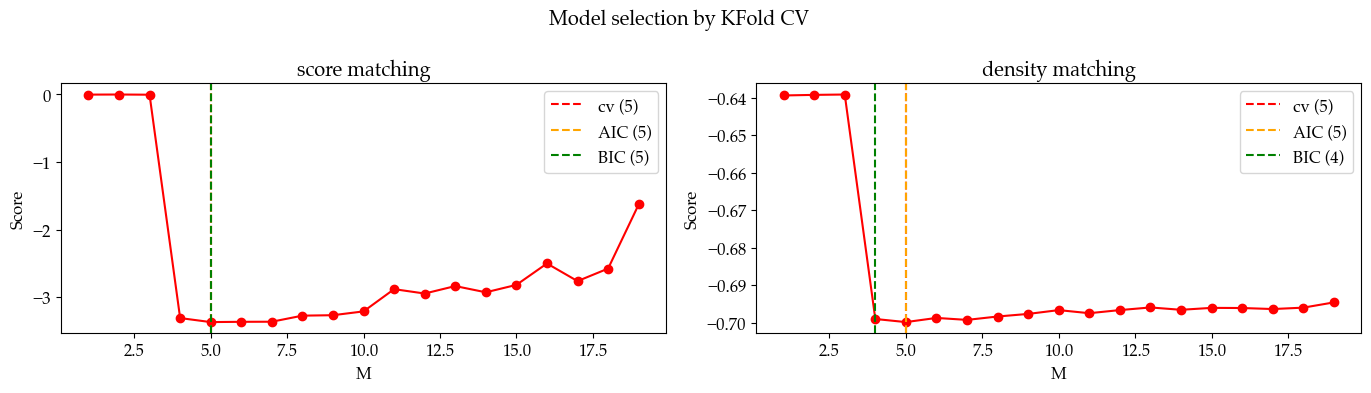

In [22]:
# --- score matching (left) ---
Mstar_score, scores = select_M_by_scoreMatchingKFoldCV(
    manifold_type, X, M_grid,
    n_splits=8,
    return_scores=True,
    random_state=None,
    rho=1e-3,
    tryearlystop=False
)

# --- density matching (right) ---
Mstar_dens, cvscores = select_M_by_DensityKFoldCV(
    manifold_type, X, M_grid,
    n_splits=8,
    n_grid_samples=1000,
    return_scores=True
)

if True:
    M_grid_score = M_grid[:len(scores)]
    M_grid_dens = M_grid[:len(cvscores)]

    fig, axs = plt.subplots(1, 2, figsize=(14, 4), sharex=False, sharey=False)
    fig.suptitle("Model selection by KFold CV")

    # left: score matching
    axs[0].plot(M_grid_score, scores, marker="o", color="red")
    axs[0].axvline(Mstar_score["cv"], color="red", linestyle="--", label=f'cv ({Mstar_score["cv"]})')
    axs[0].axvline(Mstar_score["AIC"], color="orange", linestyle="--", label=f'AIC ({Mstar_score["AIC"]})')
    axs[0].axvline(Mstar_score["BIC"], color="green", linestyle="--", label=f'BIC ({Mstar_score["BIC"]})')
    axs[0].set_title("score matching")
    axs[0].set_xlabel("M")
    axs[0].set_ylabel("Score")
    axs[0].legend()

    # right: density matching
    axs[1].plot(M_grid_dens, cvscores, marker="o", color="red")
    axs[1].axvline(Mstar_dens["cv"], color="red", linestyle="--", label=f'cv ({Mstar_dens["cv"]})')
    axs[1].axvline(Mstar_dens["AIC"], color="orange", linestyle="--", label=f'AIC ({Mstar_dens["AIC"]})')
    axs[1].axvline(Mstar_dens["BIC"], color="green", linestyle="--", label=f'BIC ({Mstar_dens["BIC"]})')
    axs[1].set_title("density matching")
    axs[1].set_xlabel("M")
    axs[1].set_ylabel("Score")
    axs[1].legend()

    plt.tight_layout()
    plt.show()